## Notebook summary

| Item | Details |
| --- | --- |
| Purpose | DenseNet-121 Final Natural-Orientation Loss Ablation |
| Model / workflow | DenseNet-121/201 |
| Input | not reported |
| Loss | Cross-Entropy (CE) |
| Training / pipeline | 3-stage training |
| Result | Run directory: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_06-30-25_175448_UTC_final_noncanonical_loss_ablation; Controlled loss arms:; "loss_type": "ce", |


# DenseNet-121 Final Natural-Orientation Loss Ablation

This is the final controlled experiment for the production DenseNet-121 KL grader.
It keeps natural left/right orientation, trains horizontal-flip invariance, preserves
the complete YOLO knee ROI, and changes only the loss function between arms.

Three losses are compared with the same split, seed, sampler, native-CAM head,
augmentations, optimizer, learning rates, and 5/15/10 epoch schedule:

- `ce`: standard five-class cross-entropy control.
- `ordinal_pd2`: the five-logit adjustable ordinal loss (PD-2) described by Chen et
  al. for this same public knee-OA dataset.
- `ce_plus_ordinal_pd2`: CE plus 0.25 times normalized PD-2, retaining probability
  calibration while penalizing distant KL errors.

CORN is intentionally excluded from this final comparison because it changes the
classifier to four conditional logits. That would no longer be the same architecture
and each native map would represent an ordinal threshold rather than a KL class.
The test split is evaluated exactly once, for the validation-selected winner.


## Execution

Run every cell from top to bottom in one Colab runtime. Expect three complete
30-epoch trainings. Every arm receives its own timestamped checkpoint directory,
validation metrics, native-CAM audit, and worst-case montage. Selection uses only
validation QWK, macro F1, and macro AP; test is opened once for the winner.


In [ ]:
import csv
import gc
import hashlib
import json
import os
import random
import subprocess
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import tqdm
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    precision_recall_fscore_support,
    recall_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("Not running in Colab; Drive mount skipped.")

try:
    import timm
except ImportError:
    subprocess.run(["pip", "install", "-q", "timm"], check=True)
    import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# fix every RNG so the three loss arms differ only by their loss, not by luck
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

dataset_zip = Path("/content/drive/MyDrive/Datasets/kaggle_knee_osteoarthritis.zip")
if dataset_zip.exists():
    subprocess.run(
        ["unzip", "-q", "-o", str(dataset_zip), "-d", "/content/Datasets"],
        check=True,
    )

DATASET_ROOT = Path("/content/Datasets/kaggle_knee_osteoarthritis")
RUN_TIMESTAMP = datetime.now(timezone.utc).strftime(
    "%Y-%m-%d_%H-%M-%S_%f_UTC"
)
# one directory per run, named by UTC timestamp; exist_ok=False so a re-run
# can never silently overwrite a previous ablation's artifacts
RUN_DIR = Path("/content/drive/MyDrive/Models/densenet121_checkpoints") / f"{RUN_TIMESTAMP}_final_noncanonical_loss_ablation"
RUN_DIR.mkdir(parents=True, exist_ok=False)
print(f"Run directory: {RUN_DIR}")

Mounted at /content/drive
Device: cuda
GPU: Tesla T4
Run directory: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_06-30-25_175448_UTC_final_noncanonical_loss_ablation


## Data Preparation and Fixed Loss Arms

All arms retain the original laterality. Training uses horizontal flipping as an
invariance augmentation; validation and test are deterministic. Square padding and
direct resizing retain the entire detected knee ROI, including marginal osteophytes.


In [ ]:
# pad the short side with black until the image is square, keeping it centred
# example: 180x300 -> pad 60 left and 60 right -> 300x300
# done before Resize so the aspect ratio of the knee is never distorted
class SquarePad:
    def __call__(self, image):
        height, width = image.shape[:2]
        side = max(height, width)
        top = (side - height) // 2
        bottom = side - height - top
        left = (side - width) // 2
        right = side - width - left
        return cv2.copyMakeBorder(
            image, top, bottom, left, right,
            cv2.BORDER_CONSTANT, value=[0, 0, 0],
        )


# contrast-limited adaptive histogram equalisation on the L (lightness) channel only
# RGB -> LAB, equalise L, LAB -> RGB; a and b keep the colour untouched
# clipLimit=2.0 here: this ablation predates the 1.25 chosen later in the CLAHE study
class CLAHE:
    def __call__(self, image):
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        lightness, channel_a, channel_b = cv2.split(lab)
        lightness = cv2.createCLAHE(
            clipLimit=2.0, tileGridSize=(8, 8)
        ).apply(lightness)
        return cv2.cvtColor(
            cv2.merge((lightness, channel_a, channel_b)),
            cv2.COLOR_LAB2RGB,
        )


# the three arms. everything else is held fixed, so any difference in the
# results is attributable to the loss function alone:
#   ce                  plain cross-entropy - treats the 5 grades as unrelated labels
#   ordinal_pd2         distance-aware loss only
#   ce_plus_ordinal_pd2 both, with the ordinal term scaled by 0.25
LOSS_SPECS = [
    {
        "name": "ce",
        "loss_type": "ce",
        "ordinal_weight": 0.0,
    },
    {
        "name": "ordinal_pd2",
        "loss_type": "ordinal_pd2",
        "ordinal_weight": 1.0,
    },
    {
        "name": "ce_plus_ordinal_pd2",
        "loss_type": "ce_plus_ordinal_pd2",
        "ordinal_weight": 0.25,
    },
]


# no laterality flip here: the earlier ablation already settled that question,
# so this notebook trains on knees in their natural orientation with p=0.5 flips
training_transform = transforms.Compose([
    SquarePad(),
    CLAHE(),
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.50),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.RandomErasing(
        p=0.10,
        scale=(0.02, 0.05),
        ratio=(0.5, 2.0),
        value=0,
    ),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


evaluation_transform = transforms.Compose([
    SquarePad(),
    CLAHE(),
    transforms.ToPILImage(),
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


# sha256 of the file bytes, read in 1 MB chunks so large files do not load into memory
def file_digest(path):
    digest = hashlib.sha256()
    with open(path, "rb") as image_file:
        for chunk in iter(lambda: image_file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


# list one split and return (paths, labels, hashes)
# two things are filtered out by content hash, not by filename:
#   - duplicates inside this split
#   - anything whose bytes already appeared in excluded_hashes (an earlier split)
# this is what stops the same image leaking from train into val or test
def index_split(split, excluded_hashes=None):
    split_dir = DATASET_ROOT / split
    if not split_dir.is_dir():
        raise FileNotFoundError(f"Dataset split is missing: {split_dir}")
    excluded_hashes = excluded_hashes or set()
    retained_hashes, paths, labels = set(), [], []
    for grade in range(5):
        grade_dir = split_dir / str(grade)
        for path in sorted(grade_dir.iterdir()):
            if path.suffix.lower() not in {".png", ".jpg", ".jpeg"}:
                continue
            digest = file_digest(path)
            if digest in excluded_hashes or digest in retained_hashes:
                continue
            retained_hashes.add(digest)
            paths.append(str(path))
            labels.append(grade)
    print(f"{split}: {len(paths)} unique images")
    return paths, labels, retained_hashes


class KneeDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        image = cv2.imread(path)
        if image is None:
            raise IOError(f"Could not read image: {path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return self.transform(image), self.labels[index], path

In [ ]:
train_paths, train_labels, train_hashes = index_split("train")
validation_paths, validation_labels, validation_hashes = index_split(
    "val", train_hashes
)
print("Train class counts:", dict(sorted(Counter(train_labels).items())))
print("Controlled loss arms:")
for spec in LOSS_SPECS:
    print(json.dumps(spec, indent=2))


train: 5778 unique images
val: 826 unique images
Train class counts: {0: 2286, 1: 1046, 2: 1516, 3: 757, 4: 173}
Controlled loss arms:
{
  "name": "ce",
  "loss_type": "ce",
  "ordinal_weight": 0.0
}
{
  "name": "ordinal_pd2",
  "loss_type": "ordinal_pd2",
  "ordinal_weight": 1.0
}
{
  "name": "ce_plus_ordinal_pd2",
  "loss_type": "ce_plus_ordinal_pd2",
  "ordinal_weight": 0.25
}


## Fixed Model: Five-Class Native-CAM DenseNet-121

A bias-free 1x1 class convolution followed by global average pooling produces five
KL logits. Each native CAM is therefore the positive spatial contribution to one
specific grade logit. The model architecture is identical in every loss arm.


In [ ]:
# 'native CAM' head: the class map IS the heatmap, so no gradients are needed to
# explain a prediction. compare with the production model:
#   production : features -> global average pool -> Linear(1024, 5)
#   native CAM : features -> Conv2d 1x1 (1024 -> 5) -> global average pool
# both give 5 logits, but here the tensor before pooling is already 5 spatial maps,
# one per KL grade - reading map[k] straight off gives the CAM for grade k
class DenseNet121NativeCAM(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            "densenet121",
            pretrained=pretrained,
            # features_only + out_indices=(4,): keep only the last feature map, drop timm's
            # own classifier. output is (batch, 1024, 12, 12) for a 384x384 input
            features_only=True,
            out_indices=(4,),
        )
        channels = self.backbone.feature_info.channels()[0]
        # 1x1 conv = one Linear applied independently at every spatial position
        # turns (batch, 1024, 12, 12) into (batch, 5, 12, 12)
        self.class_conv = nn.Conv2d(channels, 5, kernel_size=1)

    def class_maps(self, images):
        return self.class_conv(self.backbone(images)[0])

    def forward(self, images):
        # average the 5 maps over height and width -> one logit per class
        return self.class_maps(images).mean(dim=(2, 3))

    # return the heatmap for a chosen class. no backward pass anywhere in this method
    def native_cam(self, images, class_indices=None):
        with torch.no_grad():
            maps = self.class_maps(images)
            logits = maps.mean(dim=(2, 3))
            if class_indices is None:
                class_indices = logits.argmax(dim=1)
            class_indices = torch.as_tensor(
                class_indices, device=images.device, dtype=torch.long
            ).reshape(-1)
            selected = maps[
                torch.arange(images.size(0), device=images.device),
                class_indices,
            ]
            # keep only positive evidence for the class, then add a channel axis for interpolate
            selected = F.relu(selected).unsqueeze(1)
            selected = F.interpolate(
                selected,
                # 12x12 map -> upsample back to 384x384 so it can be overlaid on the input
                size=images.shape[-2:],
                mode="bilinear",
                align_corners=False,
            ).squeeze(1)
            # normalise each map to [0, 1] by its own maximum
            # clamp_min avoids dividing by zero when ReLU zeroed the whole map
            maxima = selected.flatten(1).amax(1).clamp_min(1e-8)
            selected = selected / maxima[:, None, None]
        return selected, logits

    # stage 1 (warm-up): only the new 1x1 conv learns; ImageNet features stay put
    def freeze_backbone(self):
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False
        for parameter in self.class_conv.parameters():
            parameter.requires_grad = True

    # stage 2 (coarse): open the last two dense blocks - the stages holding the most
    # task-specific features - plus the head. raise if the names ever stop matching,
    # otherwise a silent no-op would train nothing
    def unfreeze_final_stages(self):
        for parameter in self.parameters():
            parameter.requires_grad = False
        matched = 0
        for name, parameter in self.backbone.named_parameters():
            if any(token in name for token in ("denseblock3", "denseblock4")):
                parameter.requires_grad = True
                matched += parameter.numel()
        if matched == 0:
            raise RuntimeError("Could not resolve the final backbone stages.")
        for parameter in self.class_conv.parameters():
            parameter.requires_grad = True

    def unfreeze_all(self):
        for parameter in self.parameters():
            parameter.requires_grad = True

## Shared Training, Validation, and CAM Audit

Every arm resets to seed 42 and trains for 5/15/10 epochs. The validation selector
is `0.55*QWK + 0.30*macro-F1 + 0.15*macro-AP`; Grade-1 recall is reported but is not
rewarded directly, preventing the fully balanced sampler from gaming selection by
overpredicting Grade 1. Native-CAM is audited on up to 50 validation cases per grade.


In [7]:

# distance-aware loss. cross-entropy only asks 'was the right class picked?';
# this asks 'how many grades away is the probability mass sitting?'
#
#   distance_k    = |k - true|                   how far grade k is from the truth
#   expected_pd2  = sum_k p_k * 2*distance_k     expected distance under the model
#   loss          = (expected_pd2 / 2*(K-1))^2   normalise to [0,1], then square
#
# example, true grade = 2, K = 5:
#   p = [0, 0, 1, 0, 0]        -> expected 0     -> loss 0      (perfect)
#   p = [0, 0.5, 0.5, 0, 0]    -> expected 1     -> loss 0.0156 (one grade off)
#   p = [1, 0, 0, 0, 0]        -> expected 4     -> loss 0.25   (two grades off)
# squaring makes a distant mistake much more expensive than a neighbouring one -
# the same idea QWK uses when scoring
def adjustable_ordinal_pd2(logits, labels):
    """Chen et al. PD-2 ordinal loss, normalized for stable optimization."""
    probabilities = F.softmax(logits.float(), dim=1)
    grades = torch.arange(logits.size(1), device=logits.device)
    # broadcast (1,K) against (B,1) to get a (B,K) distance matrix in one step
    # example for true=[2,0]: [[2,1,0,1,2], [0,1,2,3,4]]
    distance = (grades[None, :] - labels[:, None]).abs().float()
    expected_pd2 = (probabilities * (2.0 * distance)).sum(dim=1)
    # Divide by the maximum PD-2 distance before squaring.
    # 2*(K-1) = 8 is the largest possible expected distance, so the ratio lands in [0,1]
    return (expected_pd2 / (2.0 * (logits.size(1) - 1))).square().mean()


# one switch so the training loop never needs to know which arm it is running
def calculate_loss(logits, labels, spec):
    if spec["loss_type"] == "ce":
        return F.cross_entropy(logits, labels)
    ordinal = adjustable_ordinal_pd2(logits, labels)
    if spec["loss_type"] == "ordinal_pd2":
        return ordinal
    if spec["loss_type"] == "ce_plus_ordinal_pd2":
        # combined arm: CE keeps the argmax sharp, the ordinal term pulls stray
        # probability mass toward neighbouring grades. weight 0.25 chosen up front
        return F.cross_entropy(logits, labels) + spec["ordinal_weight"] * ordinal
    raise ValueError(f"Unsupported loss: {spec['loss_type']}")


def calculate_metrics(labels, predictions, probabilities):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    probabilities = np.asarray(probabilities)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, labels=[0, 1, 2, 3, 4],
        average="macro", zero_division=0
    )
    grade1_precision, grade1_recall, _, _ = precision_recall_fscore_support(
        labels == 1, predictions == 1, average="binary", zero_division=0
    )
    # AP and AUC need one-vs-rest targets, not class indices
    # example: label 2 -> [0, 0, 1, 0, 0].  np.eye(5)[[2, 0]] gives both rows at once
    one_hot = np.eye(5)[labels]
    metrics = {
        "accuracy": float(accuracy_score(labels, predictions)),
        "qwk": float(cohen_kappa_score(labels, predictions, weights="quadratic")),
        # mean absolute error in grades - a direct read of 'how many grades off on average'
        # reported here because the ordinal arms are meant to improve exactly this
        "mae": float(np.mean(np.abs(labels - predictions))),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
        "grade1_precision": float(grade1_precision),
        "grade1_recall": float(grade1_recall),
        "macro_ap": float(average_precision_score(one_hot, probabilities, average="macro")),
        "macro_auc": float(roc_auc_score(one_hot, probabilities, average="macro")),
    }
    metrics["selection_score"] = float(
        # selection score, same weights as production: 0.55 QWK + 0.30 macro F1 + 0.15 macro AP
        0.55 * metrics["qwk"]
        + 0.30 * metrics["macro_f1"]
        + 0.15 * metrics["macro_ap"]
    )
    return metrics


def train_one_epoch(model, loader, optimizer, scaler, spec, description):
    model.train()
    running_loss = 0.0
    for images, labels, _ in tqdm.tqdm(loader, desc=description, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        # run the forward pass in float16 where it is safe: ~2x faster and half the memory.
        # master weights stay float32, so accuracy is essentially unchanged
        with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
            logits = model(images)
            loss = calculate_loss(logits, labels, spec)
        # multiply the loss by a large factor before backward.
        # float16 underflows below ~6e-8, so small gradients would otherwise become 0
        scaler.scale(loss).backward()
        # divide the gradients back by that factor BEFORE clipping.
        # clipping scaled gradients would compare them against the wrong threshold -
        # this line is why the order unscale -> clip -> step matters
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        # skips the update entirely if any gradient is inf/nan, then lowers the scale factor
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * labels.size(0)
    return running_loss / len(loader.dataset)


def evaluate(model, loader, spec, description):
    model.eval()
    labels_all, predictions_all, probabilities_all, paths_all = [], [], [], []
    total_loss = 0.0
    with torch.no_grad():
        for images, labels, paths in tqdm.tqdm(loader, desc=description, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)
            probabilities = F.softmax(logits.float(), dim=1)
            total_loss += calculate_loss(logits, labels, spec).item() * labels.size(0)
            labels_all.extend(labels.cpu().numpy())
            predictions_all.extend(probabilities.argmax(1).cpu().numpy())
            probabilities_all.extend(probabilities.cpu().numpy())
            paths_all.extend(paths)
    metrics = calculate_metrics(labels_all, predictions_all, probabilities_all)
    metrics["loss"] = total_loss / len(loader.dataset)
    return metrics, np.asarray(labels_all), np.asarray(predictions_all), np.asarray(probabilities_all), paths_all



def load_checkpoint(path):
    """Load experiment checkpoints across PyTorch versions."""
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# does the heatmap look at the joint, or somewhere it should not?
# three fixed rectangles as coarse anatomical proxies (fractions of image height/width):
#   joint       rows 28%-72%, cols 6%-94%   -> where the tibiofemoral space sits
#   border      everything OUTSIDE 8%-92%   -> crop edge, should stay cold
#   lower_tibia rows 72% and below          -> mid-shaft bone, not diagnostic
# returns each region's SHARE of total CAM energy, so the values sum to roughly 1
def cam_geometry(cam):
    height, width = cam.shape
    joint = np.zeros((height, width), dtype=bool)
    joint[
        int(0.28 * height):int(0.72 * height),
        int(0.06 * width):int(0.94 * width),
    ] = True
    border = np.ones((height, width), dtype=bool)
    border[
        int(0.08 * height):int(0.92 * height),
        int(0.08 * width):int(0.92 * width),
    ] = False
    lower_tibia = np.zeros((height, width), dtype=bool)
    lower_tibia[int(0.72 * height):, :] = True
    total = float(cam.sum()) + 1e-8
    peak = np.unravel_index(np.argmax(cam), cam.shape)
    return {
        "joint_energy": float(cam[joint].sum()) / total,
        "border_energy": float(cam[border].sum()) / total,
        "lower_tibia_energy": float(cam[lower_tibia].sum()) / total,
        "peak_inside_joint": int(joint[peak]),
    }


def audit_native_cam(model, dataset, output_dir, seed=42):
    rng = np.random.default_rng(seed)
    audit_indices = []
    labels_array = np.asarray(dataset.labels)
    for grade in range(5):
        grade_indices = np.flatnonzero(labels_array == grade)
        rng.shuffle(grade_indices)
        audit_indices.extend(
            grade_indices[:min(50, len(grade_indices))].tolist()
        )

    rows, cached = [], {}
    model.eval()
    for index in tqdm.tqdm(audit_indices, desc="NATIVE CAM AUDIT", leave=False):
        tensor, true_grade, path = dataset[index]
        batch = tensor[None].to(device)
        with torch.no_grad():
            logits = model(batch)
            predicted_grade = int(logits.argmax(1).item())
        predicted_cam, _ = model.native_cam(batch, [predicted_grade])
        true_cam, _ = model.native_cam(batch, [int(true_grade)])

        # Faithfulness: mask the central joint band with normalized mean pixels and
        # measure the selected-grade probability decrease.
        height, width = batch.shape[-2:]
        y0, y1 = int(0.28 * height), int(0.72 * height)
        x0, x1 = int(0.06 * width), int(0.94 * width)
        occluded = batch.clone()
        # faithfulness test: blank out the joint band and see how much confidence is lost.
        # if the model really reads the joint, masking it should cost a lot of probability;
        # a small drop means the evidence was somewhere else, whatever the heatmap shows.
        # 0.0 is the normalised mean pixel, i.e. mid-grey after ImageNet normalisation
        occluded[:, :, y0:y1, x0:x1] = 0.0
        with torch.no_grad():
            probabilities = F.softmax(logits.float(), dim=1)
            occluded_probabilities = F.softmax(model(occluded).float(), dim=1)
        occlusion_drop = float(
            probabilities[0, predicted_grade]
            - occluded_probabilities[0, predicted_grade]
        )

        # Natural-orientation robustness: flip the input, flip its CAM back, then
        # compare predictions and spatial evidence in the original coordinates.
        # robustness test: mirror the input left-right (dim 3 = width)
        flipped_batch = torch.flip(batch, dims=[3])
        with torch.no_grad():
            flipped_logits = model(flipped_batch)
            flipped_probabilities = F.softmax(flipped_logits.float(), dim=1)
        flipped_cam, _ = model.native_cam(flipped_batch, [predicted_grade])
        # flip the resulting CAM back so it can be compared in the ORIGINAL coordinates
        flipped_cam = torch.flip(flipped_cam, dims=[2])[0].cpu().numpy()
        probability_p = probabilities[0].clamp_min(1e-8)
        probability_q = flipped_probabilities[0].clamp_min(1e-8)
        # Jensen-Shannon divergence between the two prediction distributions:
        #   M      = (P + Q) / 2
        #   JS(P,Q)= 0.5*KL(P||M) + 0.5*KL(Q||M)
        # 0 means mirroring changed nothing; larger means the model is orientation-sensitive.
        # JS is used rather than KL because it is symmetric and always finite
        probability_m = 0.5 * (probability_p + probability_q)
        flip_js_divergence = float(
            0.5 * torch.sum(probability_p * torch.log(probability_p / probability_m))
            + 0.5 * torch.sum(probability_q * torch.log(probability_q / probability_m))
        )

        predicted_cam = predicted_cam[0].cpu().numpy()
        true_cam = true_cam[0].cpu().numpy()
        if predicted_cam.std() > 1e-8 and flipped_cam.std() > 1e-8:
            # same question for the heatmap: does it point at the same anatomy after mirroring?
            # 1.0 = identical evidence, near 0 = the model looked somewhere else entirely.
            # guarded by a std check because a flat CAM makes correlation undefined
            flip_cam_correlation = float(
                np.corrcoef(predicted_cam.ravel(), flipped_cam.ravel())[0, 1]
            )
        else:
            flip_cam_correlation = 0.0
        row = {
            "dataset_index": index,
            "path": path,
            "true_grade": int(true_grade),
            "predicted_grade": predicted_grade,
            "joint_occlusion_probability_drop": occlusion_drop,
            "flip_js_divergence": flip_js_divergence,
            "flip_cam_correlation": flip_cam_correlation,
            "flip_prediction_consistent": int(flipped_probabilities.argmax(1).item() == predicted_grade),
            **{
                f"predicted_{key}": value
                for key, value in cam_geometry(predicted_cam).items()
            },
            **{
                f"true_{key}": value
                for key, value in cam_geometry(true_cam).items()
            },
        }
        rows.append(row)
        cached[index] = (tensor, predicted_cam, true_cam)

    with open(output_dir / "native_cam_audit.csv", "w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=rows[0].keys())
        writer.writeheader()
        writer.writerows(rows)

    summary = {
        "audited_cases": len(rows),
        "joint_energy": float(np.mean([
            row["predicted_joint_energy"] for row in rows
        ])),
        "border_energy": float(np.mean([
            row["predicted_border_energy"] for row in rows
        ])),
        "lower_tibia_energy": float(np.mean([
            row["predicted_lower_tibia_energy"] for row in rows
        ])),
        "peak_inside_joint_rate": float(np.mean([
            row["predicted_peak_inside_joint"] for row in rows
        ])),
        "joint_occlusion_probability_drop": float(np.mean([
            row["joint_occlusion_probability_drop"] for row in rows
        ])),
        "flip_js_divergence": float(np.mean([
            row["flip_js_divergence"] for row in rows
        ])),
        "flip_cam_correlation": float(np.mean([
            row["flip_cam_correlation"] for row in rows
        ])),
        "flip_prediction_consistency": float(np.mean([
            row["flip_prediction_consistent"] for row in rows
        ])),
    }
    with open(output_dir / "native_cam_summary.json", "w") as handle:
        json.dump(summary, handle, indent=2)

    worst = sorted(
        rows,
        key=lambda row: (
            1 - row["predicted_peak_inside_joint"]
            + row["predicted_border_energy"]
            + row["predicted_lower_tibia_energy"]
        ),
        reverse=True,
    )[:8]
    mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
    figure, axes = plt.subplots(len(worst), 3, figsize=(12, 4 * len(worst)))
    for row_index, row in enumerate(worst):
        tensor, predicted_cam, true_cam = cached[row["dataset_index"]]
        image = (
            (tensor.cpu() * std + mean)
            .clamp(0, 1)
            .permute(1, 2, 0)
            .numpy()
        )
        axes[row_index, 0].imshow(image)
        axes[row_index, 0].set_title(
            f"True G{row['true_grade']} | predicted G{row['predicted_grade']}"
        )
        axes[row_index, 1].imshow(image)
        axes[row_index, 1].imshow(predicted_cam, cmap="jet", alpha=0.40)
        axes[row_index, 1].set_title("Predicted-class native CAM")
        axes[row_index, 2].imshow(image)
        axes[row_index, 2].imshow(true_cam, cmap="jet", alpha=0.40)
        axes[row_index, 2].set_title("True-class native CAM")
        for axis in axes[row_index]:
            axis.axis("off")
    figure.tight_layout()
    figure.savefig(output_dir / "native_cam_worst_cases.png", dpi=180)
    plt.close(figure)
    return summary

In [8]:
def train_arm(spec):
    seed_everything(42)
    arm_dir = RUN_DIR / spec["name"]
    arm_dir.mkdir(parents=True, exist_ok=True)

    train_dataset = KneeDataset(
        train_paths,
        train_labels,
        training_transform,
    )
    validation_dataset = KneeDataset(
        validation_paths,
        validation_labels,
        evaluation_transform,
    )
    class_counts = Counter(train_dataset.labels)
    # inverse-frequency weights: a grade with 173 images gets ~13x the draw probability
    # of one with 2286, so each batch sees all five grades
    sample_weights = [
        1.0 / class_counts[label] for label in train_dataset.labels
    ]
    sampler_generator = torch.Generator().manual_seed(42)
    loader_generator = torch.Generator().manual_seed(42)
    sampler = WeightedRandomSampler(
        sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
        generator=sampler_generator,
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=48,
        sampler=sampler,
        num_workers=4,
        pin_memory=device.type == "cuda",
        persistent_workers=True,
        generator=loader_generator,
    )
    validation_loader = DataLoader(
        validation_dataset,
        batch_size=48,
        shuffle=False,
        num_workers=4,
        pin_memory=device.type == "cuda",
        persistent_workers=True,
    )

    model = DenseNet121NativeCAM(pretrained=True).to(device)
    scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")
    stage2_path = arm_dir / "stage2_best_model.pth"
    best_path = arm_dir / "best_model.pth"
    last_path = arm_dir / "last_model.pth"
    history = []
    best_stage2_score = -float("inf")
    best_final_score = -float("inf")
    global_epoch = 0
    resume_at_stage3 = stage2_path.exists()
    if resume_at_stage3:
        resume_payload = load_checkpoint(last_path if last_path.exists() else stage2_path)
        history = resume_payload.get("history", [])
        # Stage 3 deliberately restarts from the best Stage 2 validation weights.
        global_epoch = 20
        print(
            f"{spec['name']}: found Stage 2 checkpoint; "
            "skipping warmup/coarse and resuming at Stage 3."
        )

    # three-stage schedule, 30 epochs total. the point is to avoid wrecking the
    # pretrained features with large gradients from a randomly initialised head:
    #   warmup   5  head only,            lr 3e-4
    #   coarse  15  + last 2 dense blocks, lr 3e-5 backbone / 3e-4 head
    #   finetune 10 whole network,         lr 1e-5
    for stage_name, stage_epochs in (
        ("warmup", 5), ("coarse", 15), ("finetune", 10)
    ):
        if resume_at_stage3 and stage_name in {"warmup", "coarse"}:
            continue
        if stage_name == "warmup":
            model.freeze_backbone()
            optimizer = optim.AdamW(
                model.class_conv.parameters(), lr=3e-4, weight_decay=1e-4
            )
            scheduler = None
        elif stage_name == "coarse":
            model.unfreeze_final_stages()
            optimizer = optim.AdamW(
                [
                    {
                        "params": [
                            parameter
                            for parameter in model.backbone.parameters()
                            if parameter.requires_grad
                        ],
                        "lr": 3e-5,
                    },
                    {"params": model.class_conv.parameters(), "lr": 3e-4},
                ],
                weight_decay=1e-4,
            )
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=15, eta_min=1e-7
            )
        else:
            if not stage2_path.exists():
                raise FileNotFoundError(
                    f"Stage 2 did not produce a checkpoint for {spec['name']}."
                )
            model.load_state_dict(
                load_checkpoint(stage2_path)["model_state_dict"]
            )
            model.unfreeze_all()
            optimizer = optim.AdamW(
                model.parameters(), lr=1e-5, weight_decay=1e-3
            )
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=10, eta_min=1e-7
            )

        for stage_epoch in range(stage_epochs):
            global_epoch += 1
            train_loss = train_one_epoch(
                model,
                train_loader,
                optimizer,
                scaler,
                spec,
                f"{spec['name']} | {stage_name} {stage_epoch + 1}/{stage_epochs}",
            )
            validation_metrics, _, _, _, _ = evaluate(
                model,
                validation_loader,
                spec,
                f"{spec['name']} | VALIDATE",
            )
            history.append({
                "epoch": global_epoch,
                "stage": stage_name,
                "train_loss": train_loss,
                **validation_metrics,
            })
            print(
                f"{spec['name']} | epoch {global_epoch:02d} | {stage_name} | "
                f"QWK={validation_metrics['qwk']:.4f} | "
                f"F1={validation_metrics['macro_f1']:.4f} | "
                f"G1R={validation_metrics['grade1_recall']:.4f} | "
                f"AP={validation_metrics['macro_ap']:.4f} | "
                f"selection={validation_metrics['selection_score']:.4f}"
            )
            if scheduler is not None:
                scheduler.step()

            payload = {
                "model_state_dict": model.state_dict(),
                "epoch": global_epoch,
                "stage": stage_name,
                "architecture": "final_linear_native_cam",
                "model_name": "densenet121",
                "loss_type": spec["loss_type"],
                "validation_metrics": validation_metrics,
                "history": history,
                "run_timestamp": RUN_TIMESTAMP,
                "arm": spec,
                "fixed_training_config": {
                    "input_resize": 384,
                    "input_crop": None,
                    "batch_size": 48,
                    "sampler": "full_inverse_frequency",
                    "stage_epochs": [5, 15, 10],
                    "learning_rates": [3e-4, 3e-5, 1e-5],
                    "native_cam": True,
                },
            }
            if (
                stage_name == "coarse"
                and validation_metrics["selection_score"] > best_stage2_score
            ):
                best_stage2_score = validation_metrics["selection_score"]
                torch.save(payload, stage2_path)
            if (
                stage_name == "finetune"
                and validation_metrics["selection_score"] > best_final_score
            ):
                best_final_score = validation_metrics["selection_score"]
                torch.save(payload, best_path)
            torch.save(payload, last_path)

    if not best_path.exists():
        raise RuntimeError(f"{spec['name']} produced no final checkpoint.")
    with open(arm_dir / "epoch_metrics.csv", "w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=history[0].keys())
        writer.writeheader()
        writer.writerows(history)

    best_checkpoint = load_checkpoint(best_path)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    cam_summary = audit_native_cam(model, validation_dataset, arm_dir)
    result = {
        "arm": spec,
        "checkpoint": str(best_path),
        "best_epoch": int(best_checkpoint["epoch"]),
        "validation_metrics": best_checkpoint["validation_metrics"],
        "native_cam_summary": cam_summary,
    }
    with open(arm_dir / "arm_manifest.json", "w") as handle:
        json.dump(result, handle, indent=2)

    del model, optimizer, scaler, train_loader, validation_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


arm_results = {}
for arm_spec in LOSS_SPECS:
    print(f"\n===== TRAINING {arm_spec['name']} =====")
    arm_results[arm_spec["name"]] = train_arm(arm_spec)

selected_arm_name = max(
    arm_results,
    key=lambda name: arm_results[name]["validation_metrics"]["selection_score"],
)
selected_result = arm_results[selected_arm_name]
selected_path = Path(selected_result["checkpoint"])
print(f"Validation-selected loss: {selected_arm_name}")
print(f"Selected checkpoint: {selected_path}")


===== TRAINING ce =====


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


ce: found Stage 2 checkpoint; skipping warmup/coarse and resuming at Stage 3.


ce | finetune 1/10:   0%|          | 0/121 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


ce | epoch 21 | finetune | QWK=0.7928 | F1=0.6635 | G1R=0.3922 | AP=0.7238 | selection=0.7436


...

ce_plus_ordinal_pd2 | epoch 27 | finetune | QWK=0.8084 | F1=0.6725 | G1R=0.4314 | AP=0.7292 | selection=0.7558


ce_plus_ordinal_pd2 | epoch 28 | finetune | QWK=0.8103 | F1=0.6706 | G1R=0.4248 | AP=0.7307 | selection=0.7565


ce_plus_ordinal_pd2 | epoch 29 | finetune | QWK=0.8053 | F1=0.6761 | G1R=0.4379 | AP=0.7291 | selection=0.7551


ce_plus_ordinal_pd2 | epoch 30 | finetune | QWK=0.8066 | F1=0.6783 | G1R=0.4314 | AP=0.7308 | selection=0.7567


Validation-selected loss: ce
Selected checkpoint: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_06-30-25_175448_UTC_final_noncanonical_loss_ablation/ce/best_model.pth


## One Test Evaluation for the Validation-Selected Loss

No per-arm test comparison is performed. The fixed test split is evaluated only for
the loss selected by the validation composite score.


test: 1656 unique images


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
TEST SELECTED LOSS:   0%|          | 0/35 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_numbe

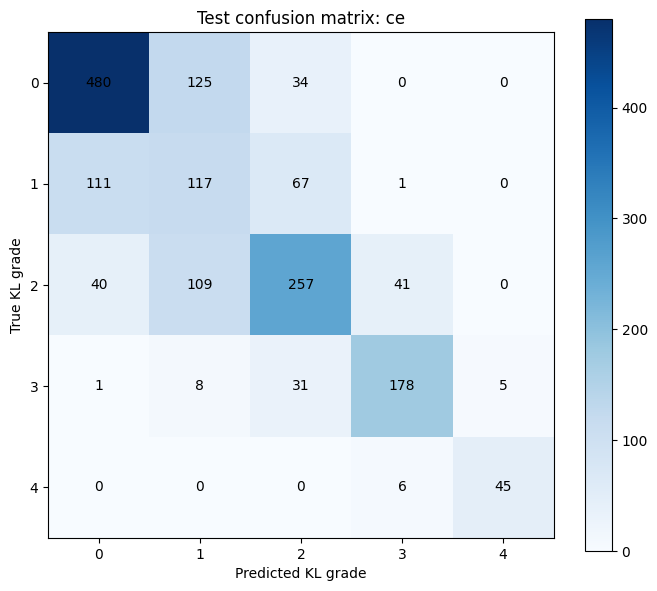

{
  "accuracy": 0.6503623188405797,
  "qwk": 0.8196540430298083,
  "mae": 0.40096618357487923,
  "macro_precision": 0.6867355926593872,
  "macro_recall": 0.6803894539964402,
  "macro_f1": 0.6822714766664381,
  "grade1_precision": 0.32590529247910865,
  "grade1_recall": 0.3952702702702703,
  "macro_ap": 0.7308651370094073,
  "macro_auc": 0.8935032718073816,
  "selection_score": 0.7651209372177371,
  "loss": 0.7856858143771904
}
              precision    recall  f1-score   support

     Grade 0       0.76      0.75      0.76       639
     Grade 1       0.33      0.40      0.36       296
     Grade 2       0.66      0.57      0.61       447
     Grade 3       0.79      0.80      0.79       223
     Grade 4       0.90      0.88      0.89        51

    accuracy                           0.65      1656
   macro avg       0.69      0.68      0.68      1656
weighted avg       0.66      0.65      0.66      1656



In [9]:
selected_spec = selected_result["arm"]
test_paths_indexed, test_labels, test_hashes = index_split(
    "test", train_hashes | validation_hashes
)
test_dataset = KneeDataset(
    test_paths_indexed,
    test_labels,
    evaluation_transform,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=48,
    shuffle=False,
    num_workers=4,
    pin_memory=device.type == "cuda",
    persistent_workers=True,
)

selected_model = DenseNet121NativeCAM(pretrained=False).to(device)
selected_checkpoint = load_checkpoint(selected_path)
selected_model.load_state_dict(selected_checkpoint["model_state_dict"])
selected_model.eval()
test_metrics, test_true, test_predicted, test_probabilities, test_paths = evaluate(
    selected_model, test_loader, selected_spec, "TEST SELECTED LOSS"
)

prediction_rows = []
for path, true_grade, predicted_grade, probabilities in zip(
    test_paths, test_true, test_predicted, test_probabilities
):
    prediction_rows.append({
        "path": path,
        "true_grade": int(true_grade),
        "predicted_grade": int(predicted_grade),
        **{
            f"grade_{grade}_probability": float(probabilities[grade])
            for grade in range(5)
        },
    })
with open(RUN_DIR / "selected_test_predictions.csv", "w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=prediction_rows[0].keys())
    writer.writeheader()
    writer.writerows(prediction_rows)
with open(RUN_DIR / "selected_test_metrics.json", "w") as handle:
    json.dump(test_metrics, handle, indent=2)

matrix = confusion_matrix(test_true, test_predicted, labels=[0, 1, 2, 3, 4])
figure, axis = plt.subplots(figsize=(7, 6))
image = axis.imshow(matrix, cmap="Blues")
for row in range(5):
    for column in range(5):
        axis.text(column, row, matrix[row, column], ha="center", va="center")
axis.set(
    title=f"Test confusion matrix: {selected_arm_name}",
    xlabel="Predicted KL grade",
    ylabel="True KL grade",
    xticks=range(5),
    yticks=range(5),
)
figure.colorbar(image, ax=axis)
figure.tight_layout()
figure.savefig(RUN_DIR / "selected_test_confusion_matrix.png", dpi=180)
plt.show()

print(json.dumps(test_metrics, indent=2))
print(classification_report(
    test_true,
    test_predicted,
    labels=[0, 1, 2, 3, 4],
    target_names=[f"Grade {grade}" for grade in range(5)],
    zero_division=0,
))


## Validation Comparison

Predictive metrics and CAM geometry are shown separately. The CAM joint band is a
coarse quantitative check, not expert lesion annotation; inspect each arm's saved
`native_cam_worst_cases.png` before promoting a checkpoint.


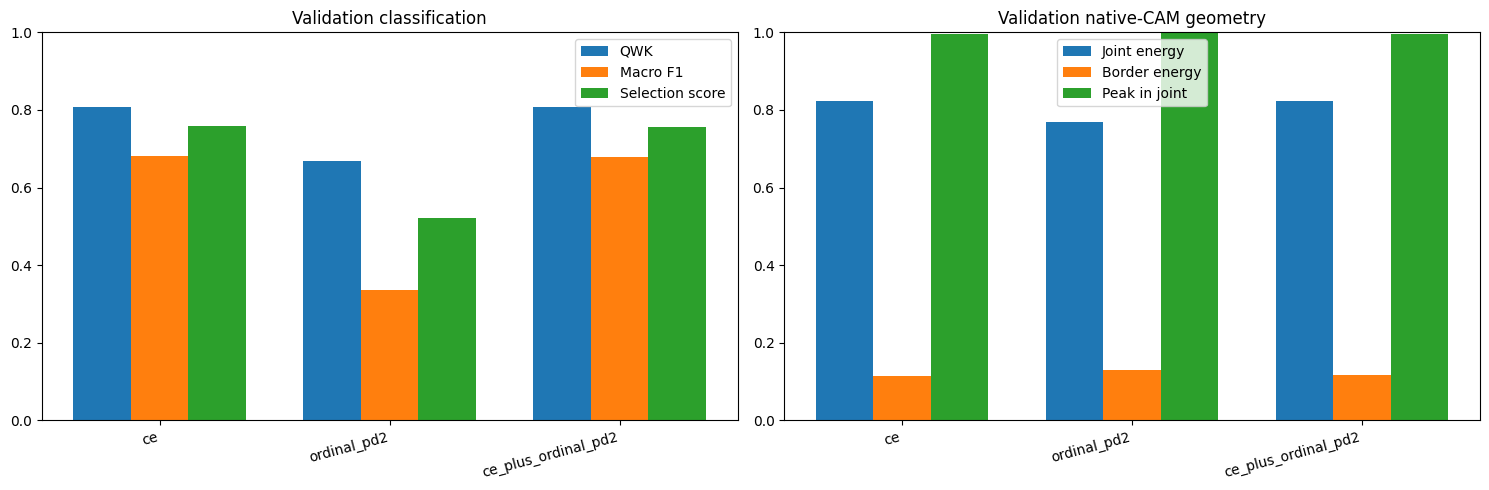

{
  "arm": "ce",
  "loss_type": "ce",
  "ordinal_weight": 0.0,
  "best_epoch": 24,
  "qwk": 0.8082722964239553,
  "macro_f1": 0.6819260640660982,
  "macro_recall": 0.6857332062036863,
  "grade1_recall": 0.38562091503267976,
  "macro_ap": 0.7310129956135603,
  "macro_auc": 0.8852521845628398,
  "selection_score": 0.758779531595039,
  "cam_joint_energy": 0.823505036558192,
  "cam_border_energy": 0.11302130852837272,
  "cam_lower_tibia_energy": 0.08835759082094681,
  "cam_peak_inside_joint_rate": 0.9955947136563876,
  "joint_occlusion_probability_drop": 0.5428139484663892,
  "flip_js_divergence": 0.018254360170362915,
  "flip_cam_correlation": 0.96087150958713,
  "flip_prediction_consistency": 0.8237885462555066,
  "checkpoint": "/content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_06-30-25_175448_UTC_final_noncanonical_loss_ablation/ce/best_model.pth"
}
{
  "arm": "ordinal_pd2",
  "loss_type": "ordinal_pd2",
  "ordinal_weight": 1.0,
  "best_epoch": 29,
  "qwk": 0.667932809994

In [10]:
comparison_rows = []
for name, result in arm_results.items():
    metrics = result["validation_metrics"]
    cam = result["native_cam_summary"]
    comparison_rows.append({
        "arm": name,
        "loss_type": result["arm"]["loss_type"],
        "ordinal_weight": result["arm"]["ordinal_weight"],
        "best_epoch": result["best_epoch"],
        "qwk": metrics["qwk"],
        "macro_f1": metrics["macro_f1"],
        "macro_recall": metrics["macro_recall"],
        "grade1_recall": metrics["grade1_recall"],
        "macro_ap": metrics["macro_ap"],
        "macro_auc": metrics["macro_auc"],
        "selection_score": metrics["selection_score"],
        "cam_joint_energy": cam["joint_energy"],
        "cam_border_energy": cam["border_energy"],
        "cam_lower_tibia_energy": cam["lower_tibia_energy"],
        "cam_peak_inside_joint_rate": cam["peak_inside_joint_rate"],
        "joint_occlusion_probability_drop": cam["joint_occlusion_probability_drop"],
        "flip_js_divergence": cam["flip_js_divergence"],
        "flip_cam_correlation": cam["flip_cam_correlation"],
        "flip_prediction_consistency": cam["flip_prediction_consistency"],
        "checkpoint": result["checkpoint"],
    })

with open(RUN_DIR / "ablation_comparison.csv", "w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=comparison_rows[0].keys())
    writer.writeheader()
    writer.writerows(comparison_rows)
with open(RUN_DIR / "ablation_results.json", "w") as handle:
    json.dump(arm_results, handle, indent=2)

names = [row["arm"] for row in comparison_rows]
x = np.arange(len(names))
figure, axes = plt.subplots(1, 2, figsize=(15, 5))
width = 0.25
for offset, key, label in (
    (-width, "qwk", "QWK"),
    (0, "macro_f1", "Macro F1"),
    (width, "selection_score", "Selection score"),
):
    axes[0].bar(
        x + offset,
        [row[key] for row in comparison_rows],
        width,
        label=label,
    )
axes[0].set_xticks(x, names, rotation=15, ha="right")
axes[0].set_ylim(0, 1)
axes[0].set_title("Validation classification")
axes[0].legend()

for offset, key, label in (
    (-width, "cam_joint_energy", "Joint energy"),
    (0, "cam_border_energy", "Border energy"),
    (width, "cam_peak_inside_joint_rate", "Peak in joint"),
):
    axes[1].bar(
        x + offset,
        [row[key] for row in comparison_rows],
        width,
        label=label,
    )
axes[1].set_xticks(x, names, rotation=15, ha="right")
axes[1].set_ylim(0, 1)
axes[1].set_title("Validation native-CAM geometry")
axes[1].legend()
figure.tight_layout()
figure.savefig(RUN_DIR / "ablation_comparison.png", dpi=180)
plt.show()

for row in comparison_rows:
    print(json.dumps(row, indent=2))


## Reproducible Experiment Report

The generated report records the exact loss definitions, fixed training config,
complete validation comparison, CAM audit, selected checkpoint, and its single test
evaluation. Do not promote a model solely because its loss value is numerically
smaller; loss scales differ. Use the shared validation metrics and CAM audit.


In [11]:
manifest = {
    "run_timestamp": RUN_TIMESTAMP,
    "run_directory": str(RUN_DIR),
    "experiment": "densenet121_final_noncanonical_loss_ablation",
    "paper_source": "https://pmc.ncbi.nlm.nih.gov/articles/PMC9531250/",
    "shared_config": {
        "architecture": "densenet121_final_linear_native_cam",
        "orientation": "natural_no_canonicalization",
        "input_resize": 384,
        "input_crop": None,
        "batch_size": 48,
        "sampler": "full_inverse_frequency",
        "augmentation": {
            "horizontal_flip_probability": 0.50,
            "rotation_degrees": 5,
            "brightness": 0.08,
            "contrast": 0.08,
            "random_erasing_probability": 0.10,
            "gamma": False,
            "gaussian_noise": False,
        },
        "ema": False,
        "seed": 42,
        "stage_epochs": [5, 15, 10],
        "learning_rates": {
            "warmup_head": 3e-4,
            "coarse_backbone": 3e-5,
            "coarse_head": 3e-4,
            "finetune_all": 1e-5,
        },
        "optimizer": "AdamW",
        "weight_decay": {"warmup_coarse": 1e-4, "finetune": 1e-3},
        "scheduler": "CosineAnnealingLR",
        "selection": "0.55*QWK + 0.30*macro_F1 + 0.15*macro_AP",
    },
    "loss_arms": arm_results,
    "selected_loss": selected_arm_name,
    "selected_checkpoint": str(selected_path),
    "selected_test_metrics": test_metrics,
}
with open(RUN_DIR / "run_manifest.json", "w") as handle:
    json.dump(manifest, handle, indent=2)
(RUN_DIR / "SELECTED_CHECKPOINT.txt").write_text(str(selected_path) + "\n")

table_rows = []
for row in comparison_rows:
    table_rows.append(
        f"| `{row['arm']}` | {row['qwk']:.4f} | {row['macro_f1']:.4f} | "
        f"{row['grade1_recall']:.4f} | {row['macro_ap']:.4f} | "
        f"{row['selection_score']:.4f} | {row['cam_joint_energy']:.4f} | "
        f"{row['cam_border_energy']:.4f} | {row['cam_peak_inside_joint_rate']:.4f} |"
    )
result_table = "\n".join(table_rows)
report = f"""# DenseNet-121 Final Natural-Orientation Loss Ablation

| Field | Value |
| --- | --- |
| Run timestamp | {RUN_TIMESTAMP} |
| Architecture | `densenet121_final_linear_native_cam` |
| Orientation | Natural; no canonicalization |
| Input | Full square-padded ROI resized to 384; no crop |
| Sampler | Full inverse-frequency |
| Selected loss | `{selected_arm_name}` |
| Selected checkpoint | `{selected_path}` |

## Validation and Native-CAM Comparison

| Loss | QWK | Macro F1 | Grade 1 recall | AP | Selection | Joint energy | Border energy | Peak in joint |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
{result_table}

## Selected Test Result

| Accuracy | QWK | MAE | Macro F1 | Macro recall | Grade 1 recall | AP | AUC |
| ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| {test_metrics['accuracy']:.4f} | {test_metrics['qwk']:.4f} | {test_metrics['mae']:.4f} | {test_metrics['macro_f1']:.4f} | {test_metrics['macro_recall']:.4f} | {test_metrics['grade1_recall']:.4f} | {test_metrics['macro_ap']:.4f} | {test_metrics['macro_auc']:.4f} |

## Decision Rule

Promote the validation-selected arm only if its CAM audit is not materially worse
than CE: joint energy must not decrease by more than 0.02, border energy must not
increase by more than 0.02, and the worst-case montage must still emphasize the
tibiofemoral joint. Otherwise retain CE even if the composite metric is slightly
higher. Native CAM remains the production explanation because this linear GAP head
makes final-layer Grad-CAM equivalent up to normalization.
"""
(RUN_DIR / "report.md").write_text(report, encoding="utf-8")
print(f"Report: {RUN_DIR / 'report.md'}")
print(f"All artifacts: {RUN_DIR}")


Report: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_06-30-25_175448_UTC_final_noncanonical_loss_ablation/report.md
All artifacts: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_06-30-25_175448_UTC_final_noncanonical_loss_ablation


In [12]:
try:
    from google.colab import runtime
    print("All artifacts saved. Releasing the Colab runtime.")
    runtime.unassign()
except ImportError:
    print("Not running in Colab; runtime release skipped.")


All artifacts saved. Releasing the Colab runtime.
